In [2]:
import numpy as np
import matplotlib.pyplot as plt 

from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

X=np.array([[1,6],
            [2,8],
            [3,7],
            [4,6],
            [5,5],])

y_labels = np.array(["F","F","P","P","P"])

le =LabelEncoder()
y=le.fit_transform(y_labels)

k=3
knn=KNeighborsClassifier(n_neighbors=k)
knn.fit(X,y)

new_student =np.array([[3.5,6.5]])
prediction =knn.predict(new_student)
print(f"prediction {le.inverse_transform(prediction)[0]}")

prediction P


In [5]:
#Create Grid

x_min ,x_max =X[:,0].min()-1, X[:,0].max()+1
y_min ,y_max =X[:,1].min()-1, X[:,1].max()+1
xx ,yy = np.meshgrid(np.arange(x_min, x_max,0.1),np.arange(y_min ,y_max ,0.1))

In [7]:
#Predict value for each point in the grid
Z= knn.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

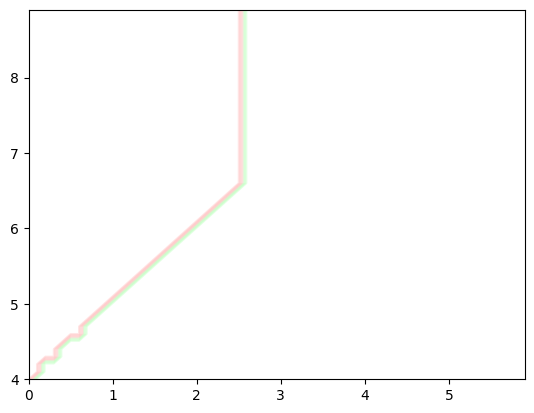

In [9]:
cmap_light = ListedColormap(['#FFAAAA','#AAFFAA'])
cmap_bold ={0:"red" ,1:"green"}


plt.contour(xx,yy,Z,  alpha=0.3 , cmap = cmap_light)
plt.show()

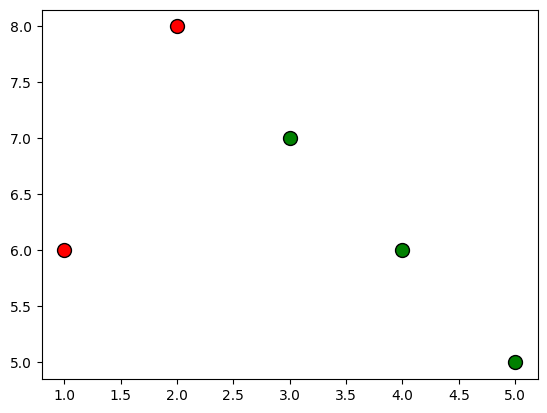

In [10]:
for class_value in np.unique(y):
    plt.scatter(
        X[y == class_value, 0],
        X[y == class_value, 1],
        c=cmap_bold[class_value],
        label=le.inverse_transform([class_value])[0],
        edgecolor='k',
        s=100
    )